In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

from sklearn.metrics import r2_score, mean_squared_error
import statsmodels.api as sm

import warnings
warnings.filterwarnings('ignore')

------------------------ DATA IMPORT AND CLEANING ------------------------

In [50]:
exchange_holdings = pd.read_csv('Exchange Holdings.csv', parse_dates=['Datetime'])
exchange_holdings['Datetime'] = exchange_holdings['Datetime'].dt.normalize()

miner_reserves = pd.read_csv('Miner Reserves.csv', parse_dates=['Datetime'])
miner_reserves['Datetime'] = miner_reserves['Datetime'].dt.normalize()

puell_multiple = pd.read_csv('Puell Multiple.csv', parse_dates=['Datetime'])
puell_multiple['Datetime'] = puell_multiple['Datetime'].dt.normalize()

hashrate = pd.read_csv('Hashrate.csv', parse_dates=['Datetime'])
hashrate['Datetime'] = hashrate['Datetime'].dt.normalize()

mean_coin_age = pd.read_csv('Mean Coin Age.csv', parse_dates=['Datetime'])
mean_coin_age['Datetime'] = mean_coin_age['Datetime'].dt.normalize()

funding_rate = pd.read_csv('Funding Rate.csv', parse_dates=['Datetime'])
funding_rate['Datetime'] = funding_rate['Datetime'].dt.normalize()

open_interest = pd.read_csv('Open Interest.csv', parse_dates=['Datetime'])
open_interest['Datetime'] = open_interest['Datetime'].dt.normalize()

fee_reward_ratio = pd.read_csv('Fee-Reward Ratio.csv', parse_dates=['Datetime'])
fee_reward_ratio['Datetime'] = fee_reward_ratio['Datetime'].dt.normalize()

active_addresses = pd.read_csv('Active Addresses.csv', parse_dates=['Datetime'])
active_addresses['Datetime'] = active_addresses['Datetime'].dt.normalize()

exchange_netflow = pd.read_csv('Exchange Netflow.csv', parse_dates=['Datetime'])
exchange_netflow['Datetime'] = exchange_netflow['Datetime'].dt.normalize()

sopr = pd.read_csv('SOPR.csv', parse_dates=['Datetime'])
sopr['Datetime'] = sopr['Datetime'].dt.normalize()

mvrv_ratio = pd.read_csv('MVRV Ratio.csv', parse_dates=['Datetime'])
mvrv_ratio['Datetime'] = mvrv_ratio['Datetime'].dt.normalize()

In [51]:
bitcoin = pd.read_csv('Bitcoin Price.csv', parse_dates=['Datetime'])
bitcoin['Datetime'] = bitcoin['Datetime'].dt.normalize()

bitcoin = bitcoin[["Datetime", "Close"]]
bitcoin["Pct Return"] = bitcoin["Close"].pct_change(-1)
bitcoin["Log Return"] = np.log(bitcoin["Close"] / bitcoin["Close"].shift(-1))

# we want to predict the next day's (t+1) return, so we shift the returns by one day
bitcoin["Pct Return Target"] = bitcoin["Pct Return"].shift(1)
bitcoin["Log Return Target"] = bitcoin["Log Return"].shift(1)

bitcoin = bitcoin.dropna()
bitcoin.head()

,Datetime,Close,Pct Return,Log Return,Pct Return Target,Log Return Target
1,2025-06-09 00:00:00+00:00,110303.871227,0.042744,0.041856,-0.012519,-0.012598
2,2025-06-08 00:00:00+00:00,105782.295477,0.001295,0.001294,0.042744,0.041856
3,2025-06-07 00:00:00+00:00,105645.525274,0.011863,0.011793,0.001295,0.001294
4,2025-06-06 00:00:00+00:00,104406.924809,0.027493,0.027122,0.011863,0.011793
5,2025-06-05 00:00:00+00:00,101613.260806,-0.029710,-0.030160,0.027493,0.027122


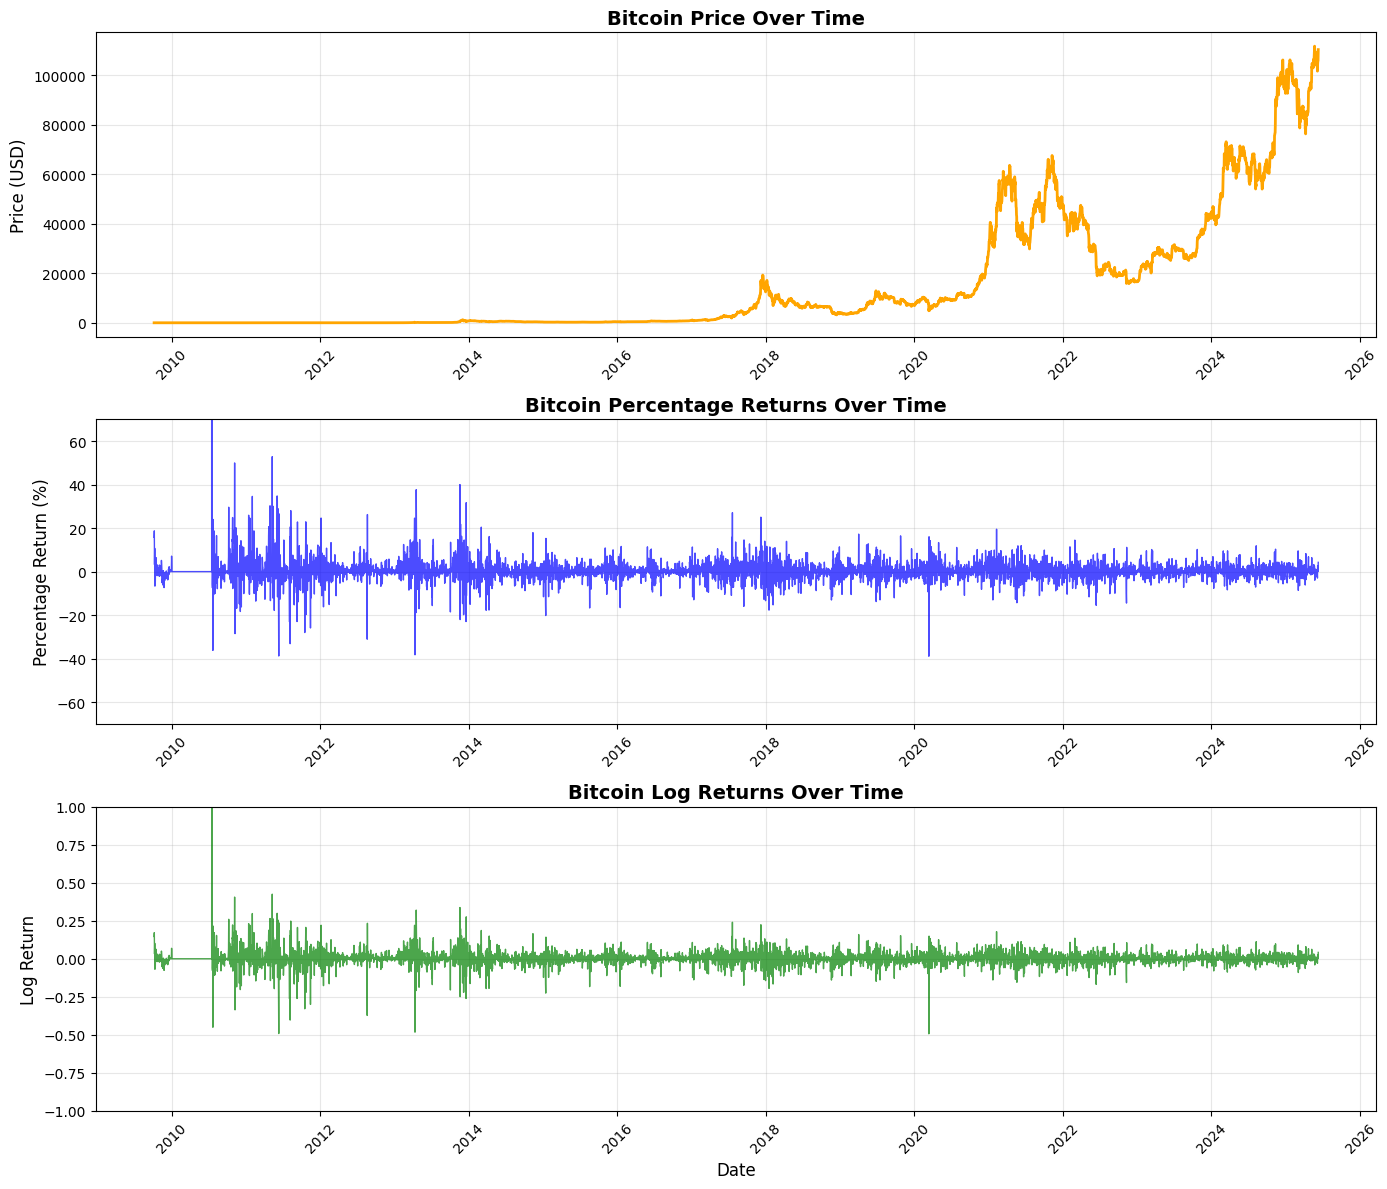

Bitcoin Data Summary Statistics:
Price Range: $0.00 - $111,699.80
Average Daily Return: 1.5580%
Return Volatility (std): 89.9045%
Max Daily Gain: 6793.43%
Max Daily Loss: -38.93%


In [75]:
# Create visualizations for Bitcoin data
fig, axes = plt.subplots(3, 1, figsize=(14, 12))

# Plot 1: Bitcoin Price Over Time
axes[0].plot(bitcoin['Datetime'], bitcoin['Close'], color='orange', linewidth=2)
axes[0].set_title('Bitcoin Price Over Time', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Price (USD)', fontsize=12)
axes[0].grid(True, alpha=0.3)
axes[0].tick_params(axis='x', rotation=45)

# Plot 2: Percentage Returns Over Time
axes[1].plot(bitcoin['Datetime'], bitcoin['Pct Return'] * 100, color='blue', linewidth=1, alpha=0.7)
axes[1].set_title('Bitcoin Percentage Returns Over Time', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Percentage Return (%)', fontsize=12)
axes[1].set_ylim(-70, 70)
axes[1].grid(True, alpha=0.3)
axes[1].tick_params(axis='x', rotation=45)

# Plot 3: Log Returns Over Time
axes[2].plot(bitcoin['Datetime'], bitcoin['Log Return'], color='green', linewidth=1, alpha=0.7)
axes[2].set_title('Bitcoin Log Returns Over Time', fontsize=14, fontweight='bold')
axes[2].set_ylabel('Log Return', fontsize=12)
axes[2].set_xlabel('Date', fontsize=12)
axes[2].set_ylim(-1, 1)  # Set y-axis limits from -1 to 1
axes[2].grid(True, alpha=0.3)
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Print some summary statistics
print("Bitcoin Data Summary Statistics:")
print("="*50)
print(f"Price Range: ${bitcoin['Close'].min():,.2f} - ${bitcoin['Close'].max():,.2f}")
print(f"Average Daily Return: {bitcoin['Pct Return'].mean()*100:.4f}%")
print(f"Return Volatility (std): {bitcoin['Pct Return'].std()*100:.4f}%")
print(f"Max Daily Gain: {bitcoin['Pct Return'].max()*100:.2f}%")
print(f"Max Daily Loss: {bitcoin['Pct Return'].min()*100:.2f}%")


In [76]:
df = exchange_holdings.merge(miner_reserves, on='Datetime', how='inner')
df = df.merge(puell_multiple, on='Datetime', how='inner')
df = df.merge(hashrate, on='Datetime', how='inner')
df = df.merge(mean_coin_age, on='Datetime', how='inner')
df = df.merge(funding_rate, on='Datetime', how='inner')
df = df.merge(open_interest, on='Datetime', how='inner')
df = df.merge(fee_reward_ratio, on='Datetime', how='inner')
df = df.merge(active_addresses, on='Datetime', how='inner')
df = df.merge(exchange_netflow, on='Datetime', how='inner')
df = df.merge(sopr, on='Datetime', how='inner')
df = df.merge(mvrv_ratio, on='Datetime', how='inner')
df = df.merge(bitcoin[["Datetime", "Pct Return Target", "Log Return Target"]], on='Datetime', how='inner')

df['Datetime'] = df['Datetime'].dt.tz_localize(None)
cutoff = pd.to_datetime('2024-01-01')                            # training period: from ????
df = df[df['Datetime'] >= cutoff].reset_index(drop=True)

df.head(20)

,Datetime,Exchange Reserve,Miner Reserve,Puell Multiple,Hashrate,Mean Coin Age,Funding Rates,Open Interest,Fee-Reward Ratio,Active Addresses,Exchange Netflow,SOPR,MVRV Ratio,Pct Return Target,Log Return Target
0,2025-06-09,2.502490e+06,1.808101e+06,1.243001,8.837253e+11,1617.120227,0.002927,3.784251e+10,0.011309,893460,-3127.633553,1.013669,2.340974,-0.012519,-0.012598
1,2025-06-08,2.505618e+06,1.807721e+06,1.337595,9.657855e+11,1616.485453,0.002124,3.604954e+10,0.006581,779831,370.863428,1.011710,2.247120,0.042744,0.041856
2,2025-06-07,2.505247e+06,1.807631e+06,1.245541,9.026623e+11,1615.764529,-0.000949,3.601397e+10,0.007294,787698,-1925.698528,1.013583,2.245429,0.001295,0.001294
3,2025-06-06,2.507173e+06,1.807638e+06,1.152875,8.458514e+11,1615.110946,-0.004703,3.543465e+10,0.010475,859500,-6228.992664,1.006889,2.220515,0.011863,0.011793
4,2025-06-05,2.513402e+06,1.807730e+06,1.156797,8.458514e+11,1614.501350,0.001402,3.385101e+10,0.011510,866463,450.194966,1.002772,2.162189,0.027493,0.027122
5,2025-06-04,2.512951e+06,1.807733e+06,1.103436,7.953528e+11,1613.870778,0.003268,3.474156e+10,0.011841,863634,-12813.432952,1.021818,2.228921,-0.029710,-0.030160
6,2025-06-03,2.525765e+06,1.808612e+06,1.267052,9.089746e+11,1614.212233,0.003108,3.547176e+10,0.010575,1019819,-22430.303958,1.027127,2.246934,-0.006325,-0.006345
7,2025-06-02,2.548195e+06,1.807708e+06,1.160714,8.395390e+11,1613.807872,0.003498,3.533606e+10,0.011359,923053,-23067.615256,1.030122,2.262955,-0.004726,-0.004737
8,2025-06-01,2.571263e+06,1.807687e+06,1.156453,8.395390e+11,1613.502044,0.001171,3.584999e+10,0.008299,827916,-2738.336903,1.004261,2.263963,0.002116,0.002114
9,2025-05-31,2.574001e+06,1.806906e+06,1.394113,1.016284e+12,1612.725264,0.001426,3.587849e+10,0.007948,839988,-2732.212849,1.001071,2.242588,0.009775,0.009727


--------------------- CORRELATION MATRIX AND ANALYSIS ---------------------

Correlation Matrix:
                  Exchange Reserve  Miner Reserve  Puell Multiple  Hashrate  \
Exchange Reserve             1.000          0.808           0.044    -0.856   
Miner Reserve                0.808          1.000           0.384    -0.775   
Puell Multiple               0.044          0.384           1.000     0.053   
Hashrate                    -0.856         -0.775           0.053     1.000   
Mean Coin Age               -0.897         -0.758          -0.166     0.807   
Funding Rates                0.288          0.289           0.481    -0.205   
Open Interest               -0.897         -0.858          -0.031     0.816   
Fee-Reward Ratio             0.390          0.490           0.248    -0.373   
Active Addresses             0.079          0.220           0.531     0.118   
Exchange Netflow             0.177          0.167           0.032    -0.115   
SOPR                         0.025          0.037           0.276     0.016   
MVRV Ratio                  -0.0

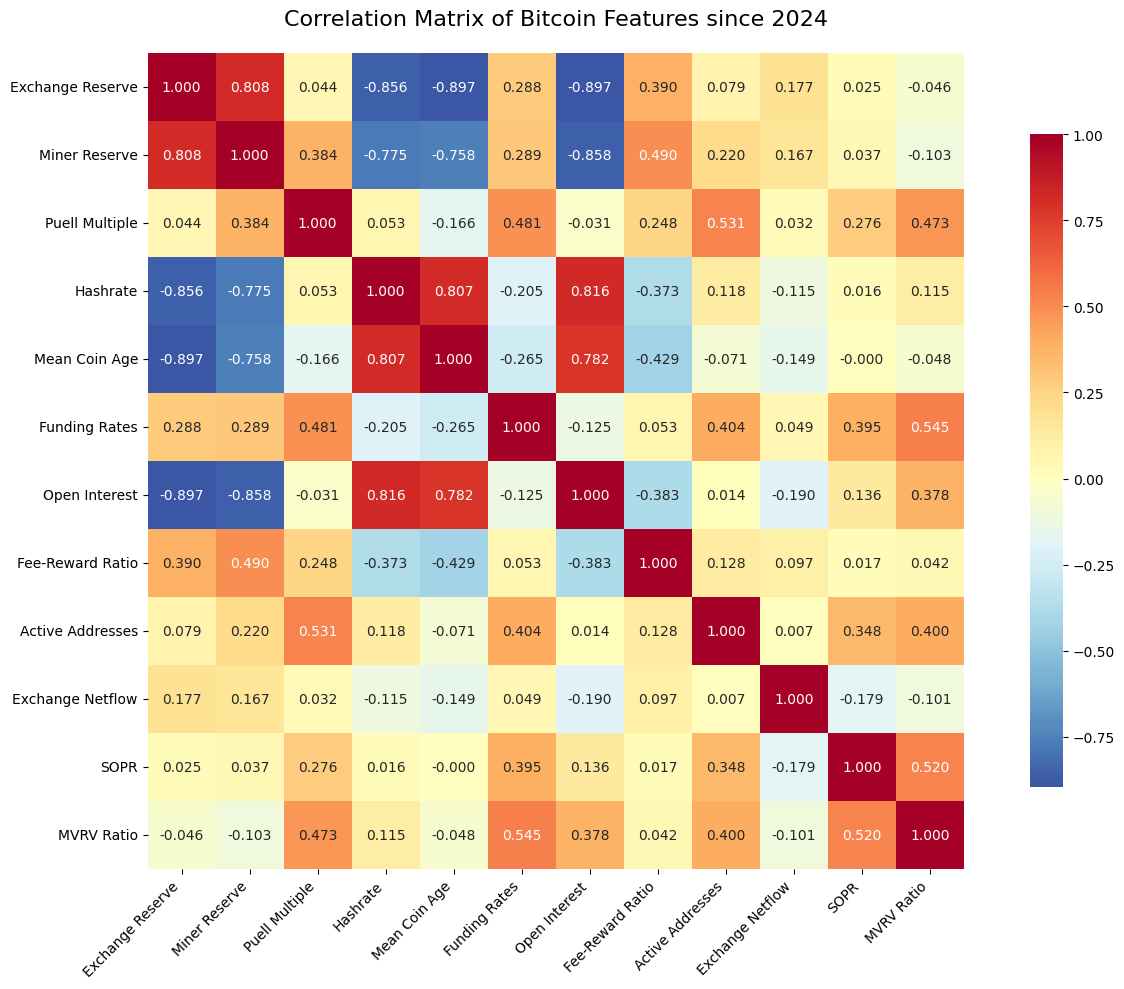


Highly Correlated Feature Pairs (|correlation| > 0.7):
Exchange Reserve - Miner Reserve: 0.808
Exchange Reserve - Hashrate: -0.856
Exchange Reserve - Mean Coin Age: -0.897
Exchange Reserve - Open Interest: -0.897
Miner Reserve - Hashrate: -0.775
Miner Reserve - Mean Coin Age: -0.758
Miner Reserve - Open Interest: -0.858
Hashrate - Mean Coin Age: 0.807
Hashrate - Open Interest: 0.816
Mean Coin Age - Open Interest: 0.782

Correlation with Log Return Target:
MVRV Ratio         -0.074
Exchange Netflow    0.064
Active Addresses    0.054
Open Interest      -0.051
Mean Coin Age       0.038
Hashrate            0.036
Fee-Reward Ratio   -0.029
Funding Rates       0.023
Miner Reserve       0.022
Puell Multiple      0.019
Exchange Reserve    0.014
SOPR               -0.011
Name: Log Return Target, dtype: float64


In [77]:
feature_cols = ["Exchange Reserve", "Miner Reserve", "Puell Multiple", "Hashrate", 
               "Mean Coin Age", "Funding Rates", "Open Interest", "Fee-Reward Ratio", 
               "Active Addresses", "Exchange Netflow", "SOPR", "MVRV Ratio"]

correlation_matrix = df[feature_cols].corr()
print("Correlation Matrix:")
print(correlation_matrix.round(3))

# HEATMAP!
plt.figure(figsize=(14, 10))
sns.heatmap(correlation_matrix, 
            annot=True, 
            cmap='RdYlBu_r', 
            center=0,
            square=True,
            fmt='.3f',
            cbar_kws={"shrink": .8})
plt.title('Correlation Matrix of Bitcoin Features since 2024', fontsize=16, pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print("\nHighly Correlated Feature Pairs (|correlation| > 0.7):")
high_corr_pairs = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        corr_val = correlation_matrix.iloc[i, j]
        if abs(corr_val) > 0.7:
            high_corr_pairs.append((correlation_matrix.columns[i], 
                                  correlation_matrix.columns[j], 
                                  corr_val))

if high_corr_pairs:
    for feature1, feature2, corr in high_corr_pairs:
        print(f"{feature1} - {feature2}: {corr:.3f}")
else:
    print("No feature pairs with correlation > 0.7 found.")

# Correlation with target variable
target_corr = df[feature_cols + ["Log Return Target"]].corr()["Log Return Target"].drop("Log Return Target")
print(f"\nCorrelation with Log Return Target:")
print(target_corr.sort_values(key=abs, ascending=False).round(3))


-------------------- REGRESSION / MODEL CONSTRUCTION --------------------

Now, we will construct our factor model. First, we have to split the data into a training set and a testing set. Then, we will fit the linear regression model and evaluate its performance. The cutoff date and split date are set to be easily changeable.

In [78]:
split_date = pd.to_datetime('2025-01-01')

X = df[["Exchange Reserve", "Miner Reserve", "Puell Multiple", "Hashrate", "Fee-Reward Ratio", "SOPR",
        "Active Addresses", "Exchange Netflow", "Funding Rates", "Mean Coin Age", "MVRV Ratio", "Open Interest"]]
y = df[["Log Return Target"]]

# split data
X_train = X[df["Datetime"] < split_date]
X_test = X[df["Datetime"] >= split_date]
y_train = y[df["Datetime"] < split_date]
y_test = y[df["Datetime"] >= split_date]


Let's use a random forest (of decision trees) to try and evaluate which factors are most important within our regression models. The Random Forest Regressor is used to predict Log Returns, and at each node, it attempts to choose the best feature / threshold to minimize MSE.

Best Parameters: {'max_depth': 5, 'max_features': 'sqrt', 'min_samples_split': 5, 'n_estimators': 300}
Tuned R² Score: -0.488128842790456


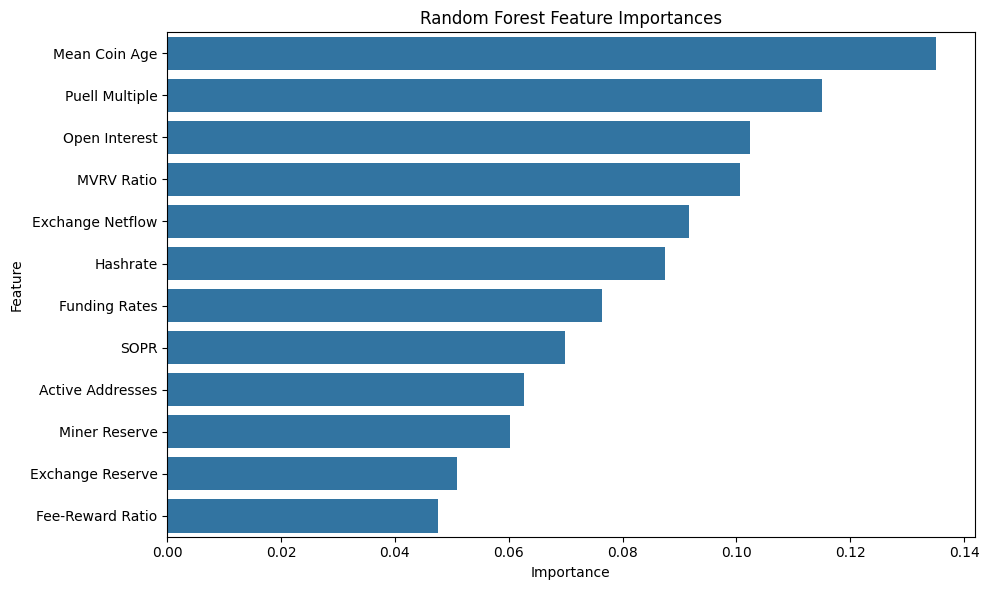

In [79]:
param_grid = {
    'n_estimators': [100, 300, 500],  # number of decision trees
    'max_depth': [5, 10, 20, None],   # maximum depth of each decision tree
    'min_samples_split': [2, 5],      # minimum samples required to split an internal node
    'max_features': ['sqrt', 'log2']  # best split criteria
}

grid = GridSearchCV(RandomForestRegressor(random_state=42),
                    param_grid, cv=5, scoring='r2', n_jobs=-1, verbose=0)
# Fix the y_train shape issue to prevent DataConversionWarning
y_train_flat = y_train.values.ravel()
grid.fit(X_train, y_train_flat)

best_rf = grid.best_estimator_
y_pred = best_rf.predict(X_test)
print("Best Parameters:", grid.best_params_)
print("Tuned R² Score:", r2_score(y_test, y_pred))

importances = best_rf.feature_importances_
features = X.columns
fi_df = pd.DataFrame({'Feature': features, 'Importance': importances})
fi_df = fi_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=fi_df, x='Importance', y='Feature')
plt.title('Random Forest Feature Importances')
plt.tight_layout()
plt.show()

In [80]:
# Linear Regression
X_train_const = sm.add_constant(X_train)
model = sm.OLS(y_train, X_train_const).fit()
print(model.summary())


# Ridge Regression (should ideally address multicollinearity, reduce overfitting)
pipeline = make_pipeline(StandardScaler(), Ridge())
param_grid = {'ridge__alpha': np.logspace(-4, 4, 20)}
tscv = TimeSeriesSplit(n_splits=5)

grid = GridSearchCV(estimator=pipeline,
                    param_grid=param_grid,
                    cv=tscv,
                    scoring='r2',
                    n_jobs=-1,
                    verbose=1)
grid.fit(X_train, y_train)

print("--------------------------------")
print("Best Parameters:", grid.best_params_)
print("Best CV R²:", grid.best_score_)

best_model = grid.best_estimator_
r2_test = best_model.score(X_test, y_test)
print("Test Set R²:", r2_test)


                            OLS Regression Results                            
Dep. Variable:      Log Return Target   R-squared:                       0.038
Model:                            OLS   Adj. R-squared:                  0.008
Method:                 Least Squares   F-statistic:                     1.267
Date:                Thu, 12 Jun 2025   Prob (F-statistic):              0.242
Time:                        13:01:20   Log-Likelihood:                 802.01
No. Observations:                 366   AIC:                            -1580.
Df Residuals:                     354   BIC:                            -1533.
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const                0.4742      1.114  